#### House Price Prediction using Machine Learning

This notebook:
1. Performs EDA
2. Cleans the dataset
3. Builds ML pipelines
4. Tunes models using GridSearchCV
5. Evaluates performance

### Import the libraries

In [1]:
!pip install xgboost
!pip install scikit-learn

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.preprocessing import PowerTransformer, RobustScaler, FunctionTransformer, PowerTransformer, OneHotEncoder
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.base import BaseEstimator, TransformerMixin
import matplotlib.pyplot as plt



### EDA & Visualization


In [3]:
house_data = pd.read_csv("https://raw.githubusercontent.com/Adegbite-Joshua/House-Price-Prediction/refs/heads/main/data.csv")


In [4]:
house_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           4600 non-null   object 
 1   price          4600 non-null   float64
 2   bedrooms       4600 non-null   float64
 3   bathrooms      4600 non-null   float64
 4   sqft_living    4600 non-null   int64  
 5   sqft_lot       4600 non-null   int64  
 6   floors         4600 non-null   float64
 7   waterfront     4600 non-null   int64  
 8   view           4600 non-null   int64  
 9   condition      4600 non-null   int64  
 10  sqft_above     4600 non-null   int64  
 11  sqft_basement  4600 non-null   int64  
 12  yr_built       4600 non-null   int64  
 13  yr_renovated   4600 non-null   int64  
 14  street         4600 non-null   object 
 15  city           4600 non-null   object 
 16  statezip       4600 non-null   object 
 17  country        4600 non-null   object 
dtypes: float

In [5]:
pd.set_option('display.max_rows', None)
house_data["waterfront"].value_counts()

waterfront
0    4567
1      33
Name: count, dtype: int64

In [6]:
house_data.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02 00:00:00,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA


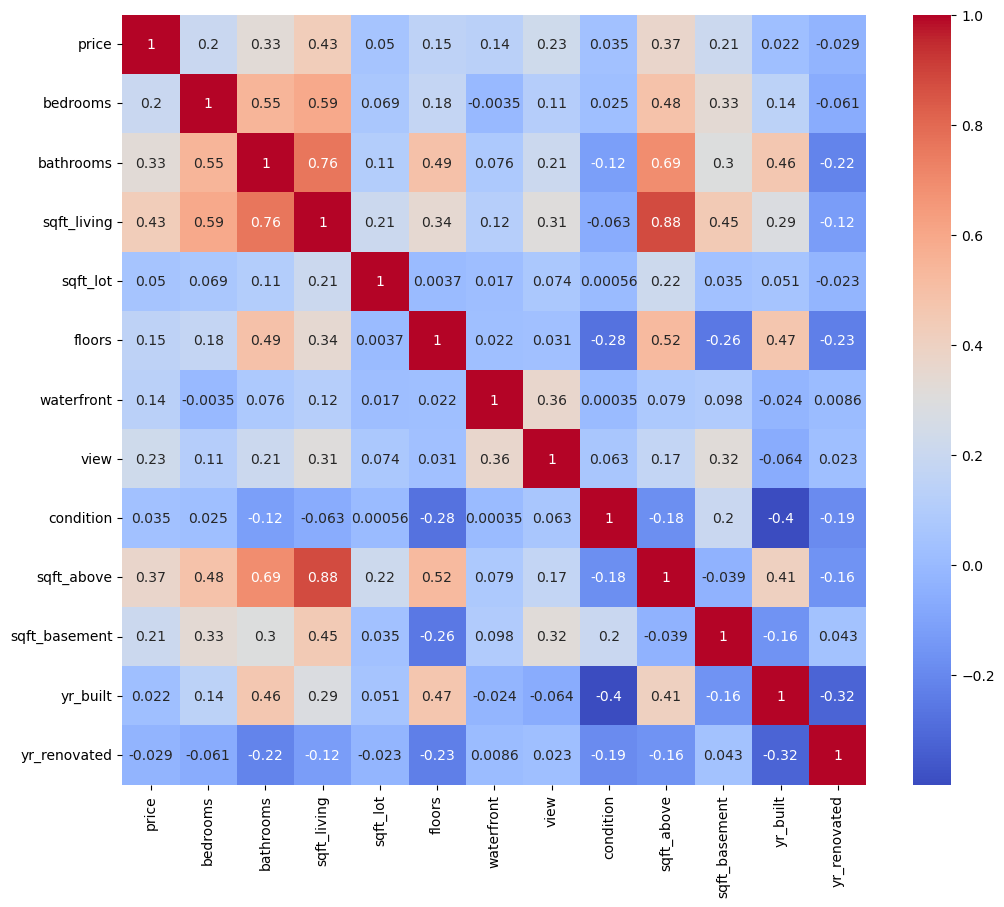

In [7]:
plt.figure(figsize=(12, 10))
sns.heatmap(house_data.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.show()

### Preprocessing

In [8]:
cols_to_check = ["price", "bedrooms", "bathrooms", "sqft_living", "sqft_lot", "floors"]

print(f"Before dropping: {len(house_data)} rows")

for col in cols_to_check:
    zero_count = (house_data[col] == 0).sum()
    zero_pct = (house_data[col] == 0).mean() * 100
    print(f"{col} zeros: {zero_count} rows ({zero_pct:.2f}%)")

# Drop rows where ANY of the columns contain 0
house_data = house_data[(house_data[cols_to_check] != 0).all(axis=1)]

print(f"After dropping: {len(house_data)} rows")

Before dropping: 4600 rows
price zeros: 49 rows (1.07%)
bedrooms zeros: 2 rows (0.04%)
bathrooms zeros: 2 rows (0.04%)
sqft_living zeros: 0 rows (0.00%)
sqft_lot zeros: 0 rows (0.00%)
floors zeros: 0 rows (0.00%)
After dropping: 4549 rows


In [9]:
for column in house_data.columns:
    print(f"Unique values in {column}: {house_data[column].nunique()} \n")

Unique values in date: 70 

Unique values in price: 1739 

Unique values in bedrooms: 9 

Unique values in bathrooms: 25 

Unique values in sqft_living: 559 

Unique values in sqft_lot: 3085 

Unique values in floors: 6 

Unique values in waterfront: 2 

Unique values in view: 5 

Unique values in condition: 5 

Unique values in sqft_above: 508 

Unique values in sqft_basement: 207 

Unique values in yr_built: 115 

Unique values in yr_renovated: 59 

Unique values in street: 4474 

Unique values in city: 44 



Unique values in statezip: 77 

Unique values in country: 1 



In [10]:
house_data.corr(numeric_only=True)["price"].sort_values(ascending=False)

price            1.000000
sqft_living      0.445042
sqft_above       0.380060
bathrooms        0.343186
view             0.242407
sqft_basement    0.218200
bedrooms         0.212814
floors           0.152010
waterfront       0.150167
sqft_lot         0.051317
condition        0.039238
yr_built         0.021444
yr_renovated    -0.029661
Name: price, dtype: float64

In [11]:
X = house_data.drop(columns=["price", "street", "country"], axis=1)
y = house_data["price"]


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
num_cols = X_train.select_dtypes(include=["int64", "float64"]).columns
cat_cols = X_train.select_dtypes(include=["object"]).columns

In [12]:
X.columns

Index(['date', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors',
       'waterfront', 'view', 'condition', 'sqft_above', 'sqft_basement',
       'yr_built', 'yr_renovated', 'city', 'statezip'],
      dtype='object')

In [13]:
class BasementTransformer(BaseEstimator, TransformerMixin):

    def __init__(self):
        pass

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        X["has_basement"] = (X["sqft_basement"] > 0).astype(int)
        X["total_sqft"] = X["sqft_lot"] + X["sqft_living"]
        X["is_renovated"] = (X["yr_renovated"] > 0).astype(int)
        X["bedrooms"] = X["bedrooms"].astype(int)
        X["house_age"] = 2026 - X["yr_built"]
        X["years_since_renovation"] = np.where(
            X["yr_renovated"] == 0, X["house_age"], 2026 - X["yr_renovated"]
        )
        X["is_modern"] = (X["yr_built"] > 2000).astype(int)
        X['luxury_bathrooms'] = (X['bathrooms'] >= 3).astype(int)
        X['bath_per_bedroom'] = X['bathrooms'] / X['bedrooms']
        X['extra_bathrooms'] = X['bathrooms'] - X['bedrooms']
        X['needs_renovation'] = (X['condition'] <= 2).astype(int)
        X['has_master_suite'] = (X['bathrooms'] >= X['bedrooms']).astype(int)
        X['multi_story'] = (X['floors'] > 1).astype(int)
        X['is_split_level'] = (X['floors'] % 1 != 0).astype(int)
        X['floor_category'] = pd.cut(
            X['floors'],
            bins=[0, 1, 2, 3, 4],
            labels=['Single', 'Two', 'Three', 'Four+']
        )
        X['premium_view'] = (X['view'] >= 3).astype(int)
        X['good_view'] = (X['view'] >= 2).astype(int)
        return X

In [14]:
def iqr_cap(X):
    X = X.copy()
    Q1 = np.percentile(X, 25, axis=0)
    Q3 = np.percentile(X, 75, axis=0)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return np.clip(X, lower_bound, upper_bound)


class NumericalTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, skew_threshold=0.5):
        self.skew_threshold = skew_threshold

    def fit(self, X, y=None):
        X = pd.DataFrame(X)

        self.numeric_cols_ = X.select_dtypes(include=[np.number]).columns
        skewness = X[self.numeric_cols_].skew()

        self.high_skew_cols_ = skewness[abs(skewness) > self.skew_threshold].index.tolist()
        self.low_skew_cols_ = skewness[abs(skewness) <= self.skew_threshold].index.tolist()

        transformers = []

        if self.high_skew_cols_:
            transformers.append(
                ('high_skew',
                 Pipeline([
                     ('cap', FunctionTransformer(iqr_cap)),
                     ('power', PowerTransformer(method='yeo-johnson')),
                     ('scale', RobustScaler())
                 ]),
                 self.high_skew_cols_)
            )

        if self.low_skew_cols_:
            transformers.append(
                ('low_skew',
                 Pipeline([
                     ('cap', FunctionTransformer(iqr_cap)),
                     ('scale', RobustScaler())
                 ]),
                 self.low_skew_cols_)
            )

        self.column_transformer_ = ColumnTransformer(
            transformers,
            remainder='passthrough'
        )

        self.column_transformer_.fit(X)

        return self

    def transform(self, X):
        return self.column_transformer_.transform(X)

In [15]:
categorical_transformer = ColumnTransformer(
    transformers=[
        ("one-hot", OneHotEncoder(), ["city", "statezip", "floor_category"])
    ],
    remainder="passthrough"
)

In [16]:
skewness = X_train[num_cols].skew()
skewed_cols = skewness[abs(skewness) > 0.5].index.tolist()


preprocessor = Pipeline(
    steps=[
        ("feat_extraction", BasementTransformer()),
        ("col_preprocessing", ColumnTransformer(
            transformers=[
                ("num", NumericalTransformer(), num_cols),
                ("cat", OneHotEncoder(handle_unknown="ignore"), ["city", "statezip"])
            ]
        ))
    ]
)

In [17]:
skewness = X_train[num_cols].skew()
skewed_cols = skewness[abs(skewness) > 0.5].index.tolist()
num_cols = X_train.select_dtypes(include=np.number).columns


preprocessor = Pipeline(
    steps=[
        ("feat_extraction", BasementTransformer()),
        ("col_preprocessing", ColumnTransformer(
            transformers=[
                ("num", NumericalTransformer(), num_cols),
                ("cat", OneHotEncoder(handle_unknown="ignore"), ["city", "statezip"])
            ]
        ))
    ]
)

### Hyper parameter tuning using GridSearchCV

In [27]:
model_pipeline = Pipeline(
    [("preprocessor", preprocessor), ("regressor", DummyRegressor())]
)


param_grid = [

    # Random Forest
    {
        "regressor": [RandomForestRegressor()],
        "regressor__n_estimators": [100, 200],
        "regressor__max_depth": [5, 10, None],
        "regressor__min_samples_split": [2, 5],
        "regressor__min_samples_leaf": [1, 2],
        "regressor__max_features": ["sqrt", "log2"],
    },

    # 🔥 Gradient Boosting
    {
        "regressor": [GradientBoostingRegressor()],
        "regressor__n_estimators": [50, 100, 200, 300],
        "regressor__learning_rate": [0.01, 0.1, 1, 0.001],
        "regressor__max_depth": [1, 3, 5, 7],
        "regressor__subsample": [0.6, 0.8, 1.0],
    },

    # 🔥🔥 XGBoost
    {
        "regressor": [XGBRegressor(objective="reg:squarederror", verbosity=0)],
        "regressor__n_estimators": [50, 100, 200, 300],
        "regressor__learning_rate": [0.01, 0.1, 1, 0.001],
        "regressor__max_depth": [3, 5, 7],
        "regressor__subsample": [0.6, 0.8, 1.0],
        "regressor__colsample_bytree": [0.6, 0.8, 1.0],
    },
]

In [28]:
grid_search = GridSearchCV(
    model_pipeline,
    param_grid,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

y_train_log = np.log1p(y_train)
grid_search.fit(X_train, y_train_log)

# Best model and parameters
print("Best Score:", -grid_search.best_score_)
print("Best Model:", grid_search.best_estimator_.named_steps['regressor'])
print("Best Params:", grid_search.best_params_)

Fitting 5 folds for each of 672 candidates, totalling 3360 fits


Best Score: 0.06523086313918317
Best Model: GradientBoostingRegressor(learning_rate=1, max_depth=1, n_estimators=300)
Best Params: {'regressor': GradientBoostingRegressor(), 'regressor__learning_rate': 1, 'regressor__max_depth': 1, 'regressor__n_estimators': 300, 'regressor__subsample': 1.0}


In [32]:
import joblib
import json
from datetime import datetime

# After grid search
best_model = grid_search.best_estimator_

# Create a comprehensive save package
model_package = {
    'model': best_model,
    'metadata': {
        'best_params': grid_search.best_params_,
        'best_score': float(grid_search.best_score_),  # Convert numpy float
        'cv_results': {
            'mean_test_score': grid_search.cv_results_['mean_test_score'].tolist(),
            'params': grid_search.cv_results_['params']
        },
        'training_date': datetime.now().isoformat(),
        'scoring_metric': grid_search.scoring,
        'n_features': X_train.shape[1] if hasattr(X_train, 'shape') else None,
        'model_type': type(best_model.named_steps['regressor']).__name__ if hasattr(best_model, 'named_steps') else type(best_model).__name__
    }
}

# Save everything
joblib.dump(model_package, 'complete_model_package.joblib')

# Load and use
loaded_package = joblib.load('complete_model_package.joblib')
loaded_model = loaded_package['model']
print(f"Best params: {loaded_package['metadata']['best_params']}")
print(f"Best score: {loaded_package['metadata']['best_score']}")

Best params: {'regressor': GradientBoostingRegressor(), 'regressor__learning_rate': 1, 'regressor__max_depth': 1, 'regressor__n_estimators': 300, 'regressor__subsample': 1.0}
Best score: -0.06523086313918317


### Evaluation

In [33]:
print(y_test[0:2].values)
print(np.expm1(grid_search.predict(X_test[0:2])))

[1225000.  496752.]
[1319011.56278444  530922.63155635]


In [34]:
def evaluate_model(pipeline, X_test, y_test):
    """
    Evaluate a model pipeline and print metrics
    """
    # Make predictions
    y_pred_log = pipeline.predict(X_test)
    y_pred = np.expm1(y_pred_log)
    
    # Calculate metrics
    from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
    
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    y_mean = y_test.mean()
    error_percentage = (rmse / y_mean) * 100
    
    # Print results
    print("=" * 50)
    print("MODEL EVALUATION METRICS")
    print("=" * 50)
    print(f"Average Price: ${y_mean:,.2f}")
    print(f"RMSE: ${rmse:,.2f}")
    print(f"MAE: ${mae:,.2f}")
    print(f"R² Score: {r2:.4f}")
    print(f"Error %: {error_percentage:.2f}%")
    print("=" * 50)
    
    return {
        'y_mean': y_mean,
        'rmse': rmse,
        'mae': mae,
        'r2': r2,
        'error_percentage': error_percentage,
        'predictions': y_pred
    }

results = evaluate_model(grid_search.best_estimator_, X_test, y_test)

MODEL EVALUATION METRICS
Average Price: $560,241.45
RMSE: $206,684.01
MAE: $101,333.45
R² Score: 0.7238
Error %: 36.89%


In [23]:
sample = X_test.iloc[[0]]
prediction = np.expm1(grid_search.predict(sample))
print("Actual price:", y_test.iloc[0])
print("Predicted price:", prediction)

Actual price: 1225000.0
Predicted price: [1319011.56278444]


In [25]:
# https://www.kaggle.com/datasets/shree1992/housedata/data